# 01 — Geometry & hierarchy (Stage 2)

Garment-scale ECG architecture model. This notebook builds the geometry and wiring that every later stage uses. The architecture is a THReaD-style hierarchy:

* **Sensor node**: an AFE+ADC for **m** electrodes, with a 2DSPI router. Sweeping m answers where the ADCs go.
* **Area**: a THReaD sub-mesh of **n** sensor nodes with one **SoC orchestrator** (the head) at its local origin.
* **Root orchestrator**: the area head nearest the garment centre. It fuses results and decides what to transmit off-body.

Links from sensor nodes to their head are star, bus or mesh. Links from heads to the root are star or mesh. Routing is Manhattan along the garment surface, which matches THReaD's XY routing inside an area. Wires may cross; crossing crosstalk is out of scope.

Specs: `Model Spec - Stage 1 Requirements` and `Model Spec - Stage 2 Parameter Space` (project docs).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import geometry as geo, params
pd.set_option('display.max_colwidth', 110); pd.set_option('display.width', 200)
g = geo.Garment(C=params.get('torso_circ'), H=params.get('torso_height'),
                Cs=params.get('sleeve_circ'), Ls=params.get('sleeve_len'))
SP = int(params.get('spares_per_site'))
params.table()

,value,low,high,unit,stage,status,source
name,,,,,,,
wear_days,7,NaN,NaN,days,1,decision,Stage 1 spec
battery_mass,1,NaN,NaN,g,1,decision,Stage 1 spec (ExG Needs allows up to ~113 g)
P_budget,0.5,0.25,1.0,mW,1,derived,"average draw at the battery: 0.1-0.15 Wh (1 g Li-ion) / 168 h = 0.6-0.9 mW, x~0.85 usable capacity, rounde..."
noise_diag,30,NaN,NaN,uVp-v,1,standard,"IEC 60601-2-25 cl. 201.12.4.106.1 (10 s, RTI)"
noise_monitor,25,NaN,NaN,uVp-p,1,assumed,"ADI monitor-grade guidance, 0.5-40 Hz; verify vs IEC 60601-2-27/-47"
...,...,...,...,...,...,...,...
rej_target_diag,89,NaN,NaN,dB,4,standard,"IEC 60601-2-25 CMR test equivalent, system level incl. DRL"
rej_target_rr,60,40.00,89.0,dB,4,assumed,R-R mode; verify vs IEC 60601-2-27/-47
irn_ch_diag,1.0,0.40,3.0,uVrms,4,assumed,"diagnostic channel IRN, 0.05-150 Hz"


## Layouts, spares, and the reference hub point

In [2]:
L = {}
for var in ['ML', 'SLV']:
    for sp in (0, SP):
        s = geo.build_layout(g, var, sp)
        L[(var, sp)] = dict(sites=s, D=geo.dist_matrix(g, s), hub=geo.central_hub(g, s))
tol = params.get('precordial_tol')
sub = pd.DataFrame({f"{v} spares={sp}": {k: f"{n} @ {d:.1f} cm" + ("" if d <= tol else "  (outside tol)")
                     for k, (n, d) in geo.nearest_substitute(g, L[(v, sp)]['sites']).items()}
                    for (v, sp) in L})
print({k: len(v['sites']) for k, v in L.items()})
sub

{('ML', 0): 64, ('ML', 1): 74, ('SLV', 0): 64, ('SLV', 1): 74}


,ML spares=0,ML spares=1,SLV spares=0,SLV spares=1
RA,G34 @ 6.0 cm (outside tol),RAs1 @ 1.5 cm,G33 @ 22.0 cm (outside tol),RAs1 @ 1.5 cm
LA,G36 @ 6.0 cm (outside tol),LAs1 @ 1.5 cm,G37 @ 22.0 cm (outside tol),LAs1 @ 1.5 cm
LL,G03 @ 6.0 cm (outside tol),LLs1 @ 1.5 cm,G03 @ 6.0 cm (outside tol),LLs1 @ 1.5 cm
RL,G01 @ 6.0 cm (outside tol),RLs1 @ 1.5 cm,G01 @ 6.0 cm (outside tol),RLs1 @ 1.5 cm
V1,G29 @ 4.9 cm (outside tol),V1s1 @ 1.5 cm,G29 @ 4.9 cm (outside tol),V1s1 @ 1.5 cm
V2,G29 @ 4.9 cm (outside tol),V2s1 @ 1.5 cm,G29 @ 4.9 cm (outside tol),V2s1 @ 1.5 cm
V3,G23 @ 4.5 cm (outside tol),V3s1 @ 1.5 cm,G23 @ 4.5 cm (outside tol),V3s1 @ 1.5 cm
V4,G23 @ 3.7 cm (outside tol),V4s1 @ 1.5 cm,G23 @ 3.7 cm (outside tol),V4s1 @ 1.5 cm
V5,G24 @ 4.2 cm (outside tol),V5s1 @ 1.5 cm,G24 @ 4.2 cm (outside tol),V5s1 @ 1.5 cm
V6,G25 @ 5.2 cm (outside tol),V6s1 @ 1.5 cm,G25 @ 5.2 cm (outside tol),V6s1 @ 1.5 cm


## Hierarchy plot: m = 4 electrodes per ADC, n = 4 nodes per area, mesh at both levels (ML, 1 spare per site)

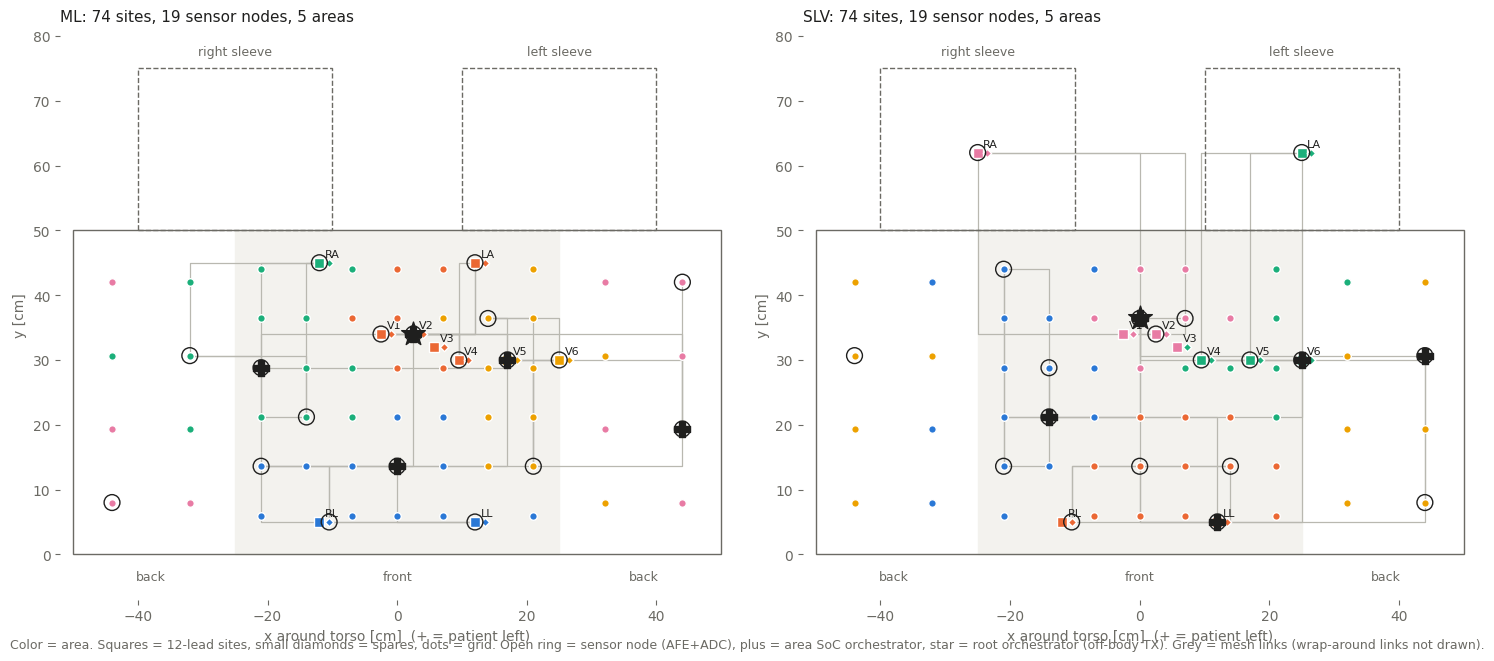

In [3]:
HUES = ['#2a78d6','#eb6834','#1baf7a','#eda100','#e87ba4','#008300','#4a3aa7','#e34948']
INK, MUTED, LINK = '#1f1f1e', '#6b6a64', '#b9b8b0'

def xy(site):
    if site.surface == 'T':  return site.a, site.b
    x0 = g.C/4 if site.surface == 'SL' else -g.C/4
    return x0 + site.a, g.H + site.b

def draw_links(ax, sites, idx, A):
    for i in range(len(idx)):
        for j in range(i+1, len(idx)):
            if A[i, j] <= 0: continue
            (x1, y1), (x2, y2) = xy(sites[idx[i]]), xy(sites[idx[j]])
            if abs(x1 - x2) > g.C/2: continue          # wraps round the back seam; not drawn
            ax.plot([x1, x2, x2], [y1, y1, y2], color=LINK, lw=0.9, zorder=1)

def draw(ax, key, m, n, title):
    d = L[key]; s, D = d['sites'], d['D']
    p = geo.build_point(g, s, D, m, n, 'mesh', 'mesh', d['hub'])
    area_of_site = {}
    for a, nodes in enumerate(p.areas):
        for ni in nodes:
            for si in p.node_clusters[ni]: area_of_site[si] = a
        ids = [p.node_sites[ni] for ni in nodes]
        draw_links(ax, s, ids, geo._mesh_edges(D[np.ix_(ids, ids)]))
    draw_links(ax, s, p.heads, geo._mesh_edges(D[np.ix_(p.heads, p.heads)]))
    ax.add_patch(Rectangle((-g.C/2, 0), g.C, g.H, fill=False, ec=MUTED, lw=1))
    ax.add_patch(Rectangle((-g.C/4, 0), g.C/2, g.H, color='#f3f2ee', zorder=0))
    for side in (1, -1):
        ax.add_patch(Rectangle((side*g.C/4 - g.Cs/2, g.H), g.Cs, g.Ls, fill=False, ec=MUTED, lw=1, ls='--'))
    for i, site in enumerate(s):
        x, y = xy(site)
        mk = {'12lead': 's', 'spare': 'D', 'grid': 'o'}[site.role]
        sz = {'12lead': 60, 'spare': 18, 'grid': 30}[site.role]
        ax.scatter(x, y, s=sz, marker=mk, color=HUES[area_of_site[i] % 8], edgecolor='white', lw=1, zorder=3)
        if site.role == '12lead':
            ax.annotate(site.name, (x, y), xytext=(4, 4), textcoords='offset points', fontsize=8, color=INK)
    for ni in p.node_sites:
        x, y = xy(s[ni]); ax.scatter(x, y, s=130, facecolor='none', edgecolor=INK, lw=1.0, zorder=4)
    for h in p.heads:
        x, y = xy(s[h]); ax.scatter(x, y, s=120, marker='P', color=INK, zorder=5)
    x, y = xy(s[p.root]); ax.scatter(x, y, s=320, marker='*', color=INK, zorder=6)
    for t, xx in (('front', 0), ('back', -g.C/2 + 12), ('back', g.C/2 - 12)):
        ax.text(xx, -4, t, ha='center', color=MUTED, fontsize=9)
    ax.text(-g.C/4, g.H + g.Ls + 2, 'right sleeve', ha='center', color=MUTED, fontsize=9)
    ax.text(g.C/4, g.H + g.Ls + 2, 'left sleeve', ha='center', color=MUTED, fontsize=9)
    ax.set_title(f"{title}: {len(s)} sites, {p.n_nodes} sensor nodes, {p.n_areas} areas", fontsize=11, color=INK, loc='left')
    ax.set_xlim(-g.C/2 - 2, g.C/2 + 2); ax.set_ylim(-7, g.H + g.Ls + 6); ax.set_aspect('equal')
    ax.set_xlabel('x around torso [cm]  (+ = patient left)', color=MUTED); ax.set_ylabel('y [cm]', color=MUTED)
    for sp_ in ax.spines.values(): sp_.set_visible(False)
    ax.tick_params(colors=MUTED)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.4))
draw(axes[0], ('ML', SP), 4, 4, 'ML'); draw(axes[1], ('SLV', SP), 4, 4, 'SLV')
fig.text(0.01, 0.01, 'Color = area. Squares = 12-lead sites, small diamonds = spares, dots = grid. Open ring = sensor node (AFE+ADC), '
         'plus = area SoC orchestrator, star = root orchestrator (off-body TX). Grey = mesh links (wrap-around links not drawn).',
         color=MUTED, fontsize=9)
plt.tight_layout(rect=(0, 0.03, 1, 1)); plt.savefig('hierarchy_m4_n4.png', dpi=160); plt.show()

## Sweep: wiring primitives for every (m, n, topology) point

These are the geometry inputs to the Stage 3 power model. Units are metres.

* `analog_*`: the electrode-to-AFE runs.
* `intra_*`: the sensor-node-to-head links.
* `inter_*`: the head-to-root links.
* `yarn` is the installed wire. `bitm` is the sum of routed path lengths from every source to its sink; multiply it by the per-source bit rate to get bit-metres. `hops` counts router traversals. `bridges` counts single-link faults that would disconnect something.

In [4]:
rows = []
for key in [('ML', SP), ('SLV', SP)]:
    d = L[key]; N = len(d['sites'])
    for m in [1, 2, 3, 4, 8, 16, N]:
        for n in [1, 2, 4, 8, N]:
            for intra in ['star', 'bus', 'mesh']:
                for inter in ['star', 'mesh']:
                    p = geo.build_point(g, d['sites'], d['D'], m, n, intra, inter, d['hub'],
                                        params.get('min_lead_spacing'))
                    rows.append(dict(variant=key[0], m='N' if m == N else m, n='all' if n == N else n,
                        intra=intra, inter=inter, sensor_nodes=p.n_nodes, areas=p.n_areas,
                        analog_total=p.analog_total_cm/100, analog_max_cm=p.analog_max_cm,
                        intra_yarn=p.intra_lv.yarn_cm/100, intra_bitm=p.intra_lv.bitm_cm/100,
                        intra_hops=p.intra_lv.hops, intra_bridges=p.intra_lv.bridges,
                        inter_yarn=p.inter_lv.yarn_cm/100, inter_bitm=p.inter_lv.bitm_cm/100,
                        inter_hops=p.inter_lv.hops, inter_bridges=p.inter_lv.bridges,
                        leads_in_node=p.leads_in_node, leads_in_area=p.leads_in_area,
                        leads_cross_area=p.leads_cross_area, nodes_local_lead=p.nodes_local_lead))
S = pd.DataFrame(rows).round(2)
S.to_csv('wiring_primitives.csv', index=False)
print(len(S), 'architecture points written to wiring_primitives.csv')
S[(S.variant == 'ML') & (S.intra == 'mesh') & (S.inter == 'mesh')].drop(columns=['variant', 'intra', 'inter'])

420 architecture points written to wiring_primitives.csv


,m,n,sensor_nodes,areas,analog_total,analog_max_cm,intra_yarn,intra_bitm,intra_hops,intra_bridges,inter_yarn,inter_bitm,inter_hops,inter_bridges,leads_in_node,leads_in_area,leads_cross_area,nodes_local_lead
5,1,1,74,74,0.00,0.0,0.00,0.00,0,0,12.85,22.93,344,0,0,0,12,0
11,1,2,74,37,0.00,0.0,2.74,2.74,37,37,10.90,12.27,124,0,0,0,12,0
17,1,4,74,19,0.00,0.0,11.23,4.34,55,0,7.95,7.16,49,0,0,0,12,0
23,1,8,74,10,0.00,0.0,16.34,7.18,91,1,6.04,3.50,15,0,0,0,12,0
29,1,all,74,1,0.00,0.0,12.85,26.79,462,0,0.00,0.00,0,0,0,12,0,0
35,2,1,37,37,2.74,25.0,0.00,0.00,0,0,10.90,12.27,124,0,0,0,12,29
41,2,2,37,19,2.74,25.0,1.80,1.80,18,18,7.59,6.89,43,0,0,0,12,29
47,2,4,37,10,2.74,25.0,7.85,2.99,27,1,5.34,3.01,14,0,0,0,12,29
53,2,8,37,5,2.74,25.0,11.52,5.64,44,1,4.34,1.41,4,0,0,0,12,29
59,2,all,37,1,2.74,25.0,10.90,12.27,124,0,0.00,0.00,0,0,0,12,0,29


## Where the ADCs go: analog run length and local leads vs m (ML)

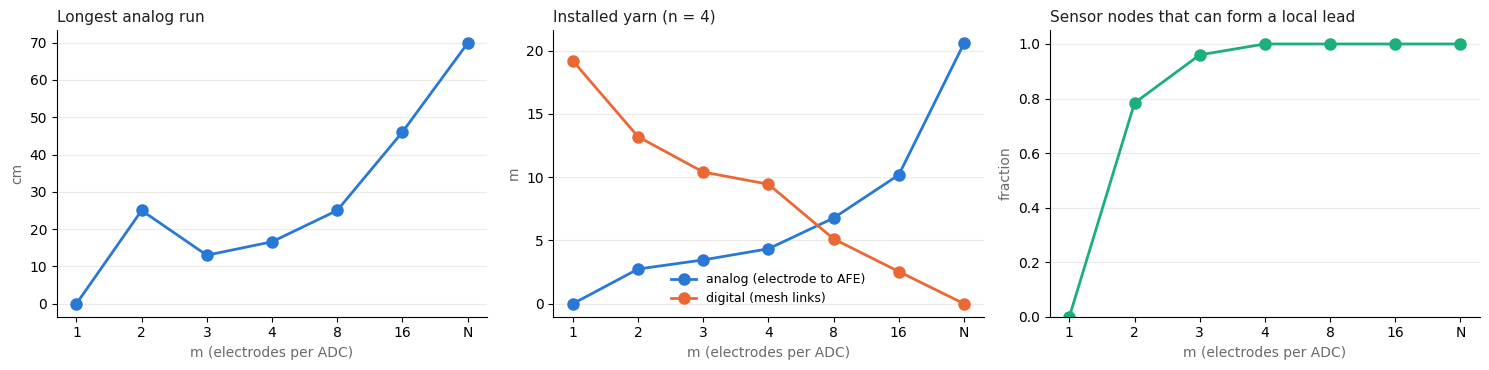

In [5]:
Q = S[(S.variant == 'ML') & (S.n == 4) & (S.intra == 'mesh') & (S.inter == 'mesh')].copy()
Q['m_lbl'] = Q.m.astype(str)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
def style(ax, t, yl):
    ax.set_title(t, loc='left', fontsize=11, color=INK); ax.set_ylabel(yl, color=MUTED); ax.set_xlabel('m (electrodes per ADC)', color=MUTED)
    ax.grid(axis='y', color='#ecebe6'); ax.set_axisbelow(True)
    for sp_ in ('top', 'right'): ax.spines[sp_].set_visible(False)
axes[0].plot(Q.m_lbl, Q.analog_max_cm, color=HUES[0], lw=2, marker='o', ms=8)
style(axes[0], 'Longest analog run', 'cm')
axes[1].plot(Q.m_lbl, Q.analog_total, color=HUES[0], lw=2, marker='o', ms=8, label='analog (electrode to AFE)')
axes[1].plot(Q.m_lbl, Q.intra_yarn + Q.inter_yarn, color=HUES[1], lw=2, marker='o', ms=8, label='digital (mesh links)')
axes[1].legend(frameon=False, fontsize=9); style(axes[1], 'Installed yarn (n = 4)', 'm')
axes[2].plot(Q.m_lbl, Q.nodes_local_lead / Q.sensor_nodes, color=HUES[2], lw=2, marker='o', ms=8)
style(axes[2], 'Sensor nodes that can form a local lead', 'fraction')
axes[2].set_ylim(0, 1.05)
plt.tight_layout(); plt.savefig('adc_placement_geometry.png', dpi=160); plt.show()

## 12-lead locality: where each lead has to be formed

In [6]:
S[(S.variant == 'ML') & (S.intra == 'mesh') & (S.inter == 'mesh') & (S.n.isin([1, 4, 'all']))][
    ['m', 'n', 'sensor_nodes', 'areas', 'leads_in_node', 'leads_in_area', 'leads_cross_area']]

,m,n,sensor_nodes,areas,leads_in_node,leads_in_area,leads_cross_area
5,1,1,74,74,0,0,12
17,1,4,74,19,0,0,12
29,1,all,74,1,0,12,0
35,2,1,37,37,0,0,12
47,2,4,37,10,0,0,12
59,2,all,37,1,0,12,0
65,3,1,25,25,0,0,12
77,3,4,25,7,0,0,12
89,3,all,25,1,0,12,0
95,4,1,19,19,0,0,12


## Hub-position sensitivity (single ADC, m = N: total analog yarn)

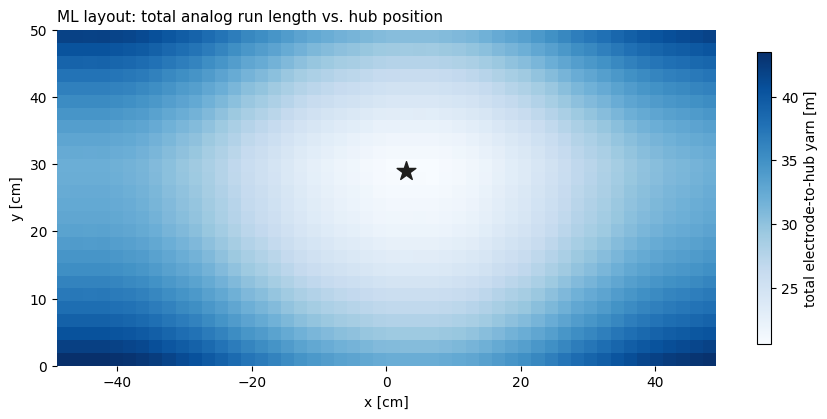

min 20.6 m at the reference hub; front-panel worst 39.1 m; global worst 43.5 m


In [7]:
s = L[('ML', SP)]['sites']
xs = np.arange(-g.C/2 + 1, g.C/2 + 1, 2.0); ys = np.arange(0, g.H + 1, 2.0)
Z = np.array([[geo.torso_point_dists(g, s, x, y).sum()/100 for x in xs] for y in ys])
fig, ax = plt.subplots(figsize=(9, 4.2))
im = ax.imshow(Z, origin='lower', extent=(xs[0], xs[-1], ys[0], ys[-1]), cmap='Blues', aspect='equal')
ax.scatter(*L[('ML', SP)]['hub'], marker='*', s=200, color=INK)
cb = plt.colorbar(im, ax=ax, shrink=0.8); cb.set_label('total electrode-to-hub yarn [m]')
ax.set_title('ML layout: total analog run length vs. hub position', loc='left', fontsize=11)
ax.set_xlabel('x [cm]'); ax.set_ylabel('y [cm]')
for sp_ in ax.spines.values(): sp_.set_visible(False)
plt.tight_layout(); plt.savefig('hub_sensitivity.png', dpi=160); plt.show()
print(f"min {Z.min():.1f} m at the reference hub; front-panel worst {Z[:, np.abs(xs) <= 25].max():.1f} m; global worst {Z.max():.1f} m")

## Prior-work mapping (Stage 2 check)

| Work | m | n | Links | Notes |
|---|---|---|---|---|
| Kuang '25 (CD-FDM DDC) | N (4 ch) | — | local | one ADC for all channels |
| Warchall '19 (FM-ADC) | N (one gateway SAR) | — | analog FDM multidrop bus | special case: active electrodes with analog link, ADC at the gateway |
| Dabbaghian '24 (AE) | 1 | all | digital TDM multidrop bus to one backend | shared CM average + DRL |
| SeisMote '20 | ≈2 | all | star, radio (E_fixed-only link) | hub processing |
| Ji '26 | 2 | 1 | none | single-node limit |
| THReaD '26 | — (no AFE) | configurable | 2DSPI mesh, hierarchical areas | provides the network, SoC and PMU layers |


## Findings from geometry alone (ML variant, 1 spare per site; to discuss)

1. **Dedicated spares fix substitution.** One spare per site, 1.5 cm away, puts every 12-lead site within tolerance, at a cost of 10 sites (74 in total). Grid neighbours were 3.7–6 cm away.
2. **Where the ADCs go: the geometry favours m = 3–4, and power will decide.**
   * With m = 3–4, the longest analog run is 13–17 cm, against 46 cm at m = 16 and 70 cm with one ADC for everything.
   * At m = 3–4, 96–100% of sensor nodes can form a local bipolar lead of at least 5 cm, so R-R and BSPM leads can be formed in analog on-node, with no network sync.
   * Total installed yarn is lowest near m = 8 (about 12 m). m = 3–4 costs about 14 m, and a single ADC costs about 21 m, all of it analog.
   * m = 3–4 is therefore the region where analog runs stay short at a modest yarn premium. The per-node overhead and the yarn capacitance (Stage 3) decide whether that premium is worth paying.
   * The m = 2 point is noisy (a 25 cm pair) because an odd-one-out site gets forced into a pair. A real design would pair sites deliberately.
3. **The 12-lead belongs at the orchestrator level.** For every m < N, no sensor node holds a complete 12-lead lead. With n = 4, 11–12 leads span more than one area. They fall inside one area only when that area covers all 10 sites (for example m = 16 with 2 areas).
   * The natural design is for the root orchestrator, or a designated "12-lead area", to gather the 10 streams in 12-lead mode.
   * That traffic is about 80 kbps raw, which is trivial for a 2DSPI link.
   * The binding constraint is sample alignment across nodes (≤ ~9 µs), not bandwidth.
4. **Mesh vs. star buys fault tolerance with yarn, not energy.** Take m = 4, n = 4:
   * A mesh inside each area has the same routed bit-metres as a star (2.3 m).
   * It uses 2.5× the yarn (5.8 vs. 2.3 m) but removes all 14 single-link failure points.
   * A multidrop bus uses about 3.7× the bit-metres, because every bit charges the whole bus.
   * Between areas, the mesh uses 3.7 vs. 1.3 m of yarn and reduces the single-link failure points from 4 to 0.
   * So energy separates the topologies only through router-hop overhead, which is now a key parameter.
5. **The hub position matters for the single-ADC case.** With m = N, total analog yarn is 20.6 m at the reference hub and rises to about 39 m if the hub moves to the edge of the front panel. This is an argument against a single central ADC beyond the Z_cm penalty.
6. **Plot caveat.** The links in the hierarchy plot are drawn as straight L-shapes. The routing model itself sends sleeve links through the shoulder junction, as the geometry defines.
